# PySpatialStats Getting Started

A progressive hands-on guide from first fit to advanced geographically weighted (GW) workflows.

**Audience:** GIS analysts, spatial econometricians, and ML practitioners new to GW methods.

**Prerequisites:** Python 3.9+, basic NumPy/pandas, and familiarity with regression concepts.

This notebook follows [TUTORIAL.md](../../TUTORIAL.md) and uses real datasets from the repository `data/` folder:

| Dataset | File | Use in this notebook |
|---|---|---|
| Northeast diabetes (counties) | `data/diabetes_northeast.csv` + `.shp` | Core GWR / MGWR / diagnostics |
| Atlantic diabetes (counties) | `data/diabetes_atlantic.csv` | End-to-end comparison workflow |
| California PM2.5 (2025) | `data/CA_pm25_2025.csv` | Spatiotemporal / ML subsample |

Run from the **repository root** so relative `data/` paths resolve.


## 1. What is PySpatialStats?

PySpatialStats is a Python package for **geographically weighted modelling** — methods where statistical relationships are allowed to vary across space (and time).

| Paradigm | Classes | When to use |
|---|---|---|
| Classical GW statistics | `GWR`, `MGWR`, `GWSS`, `GWGLM` | Interpretable local coefficients, inference |
| GW machine learning | `GWRandomForest`, `GWXGBoost`, `GWLightGBM` | Non-linear relationships, prediction |
| GW deep learning | `GNNWR`, `GTNNWR` | Complex non-stationarity, learned weights |
| Multivariate / network | `GWPCA`, `NetworkGWR` | Dimension reduction, network-constrained space |


## 2. Installation & environment check


In [1]:
import spatialstats
import spatialstats.gwmodel as gwmodel

print("spatialstats version:", spatialstats.__version__)

from spatialstats.gwmodel.linear import GWR
print("PySpatialStats ready.")


spatialstats version: 0.2.0
PySpatialStats ready.


## 3. Core concepts

Before fitting models, three ideas appear in every GW class:

1. **Coordinates** — NumPy `(n, 2)` or a GeoPandas geometry
2. **Kernel + bandwidth** — how neighbours are weighted
3. **fit → predict → score** — scikit-learn-style API


In [2]:
import numpy as np
from spatialstats.gwmodel.core.kernels import SpatialKernel

kern = SpatialKernel("bisquare", fixed=True, bandwidth=10.0)
distances = np.array([0.0, 3.0, 7.0, 12.0])
weights = kern(distances)
print("distances:", distances)
print("weights:  ", weights)


distances: [ 0.  3.  7. 12.]
weights:   [1.     0.8281 0.2601 0.    ]


## 4. Level 1 — Getting started (basic)

**Goal:** Fit your first GWR in a few lines using Northeast U.S. county diabetes data.

### 4.1 Load data from `data/`


In [3]:
from pathlib import Path
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# Resolve repo-root data/ from cwd or parents (works from repo root or examples/notebooks/)
_ROOT = Path.cwd()
for _cand in [Path.cwd(), *Path.cwd().parents]:
    if (_cand / "data" / "diabetes_northeast.csv").exists():
        _ROOT = _cand
        break
DATA = _ROOT / "data"
print("Using DATA =", DATA)

# Attribute table + projected coordinates (Albers-like metres)
df = pd.read_csv(DATA / "diabetes_northeast.csv")
gdf = gpd.read_file(DATA / "diabetes_northeast.shp")

# Align geometry with the CSV attributes via FIPS when available
if "FIPS" in gdf.columns and "FIPS" in df.columns:
    gdf = gdf.merge(df.drop(columns=[c for c in ["X", "Y"] if c in df.columns and c in gdf.columns], errors="ignore"),
                    on="FIPS", how="inner", suffixes=("", "_csv"))
else:
    # Fall back: build points from CSV X/Y
    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["X"], df["Y"]),
        crs=gdf.crs if gdf.crs is not None else None,
    )

features = [
    "Obesity",
    "Physical_Inactivity",
    "PCP_rate",
    "Food_Env_Index",
    "SVI",
]
target = "Diabetes_per"

coords = df[["X", "Y"]].values.astype(float)
X = df[features].values.astype(float)
y = df[target].values.astype(float)

print(f"n={len(df)}, X={X.shape}, y={y.shape}, coords={coords.shape}")
print("Target:", target)
print("Features:", features)
df[["County", "State", target] + features].head()


Using DATA = /home/zia207/Github/PySpatialStats/data
n=217, X=(217, 5), y=(217,), coords=(217, 2)
Target: Diabetes_per
Features: ['Obesity', 'Physical_Inactivity', 'PCP_rate', 'Food_Env_Index', 'SVI']


,County,State,Diabetes_per,Obesity,Physical_Inactivity,PCP_rate,Food_Env_Index,SVI
0,Fairfield County,Connecticut,6.42,21.48,17.34,93.8,8.5,0.6184
1,Hartford County,Connecticut,8.58,27.66,20.20,95.2,8.0,0.5955
2,Litchfield County,Connecticut,6.38,26.56,17.50,59.4,8.6,0.1512
3,Middlesex County,Connecticut,6.32,26.42,17.06,73.8,8.4,0.1843
4,New Haven County,Connecticut,8.84,29.64,20.78,88.2,7.9,0.6512


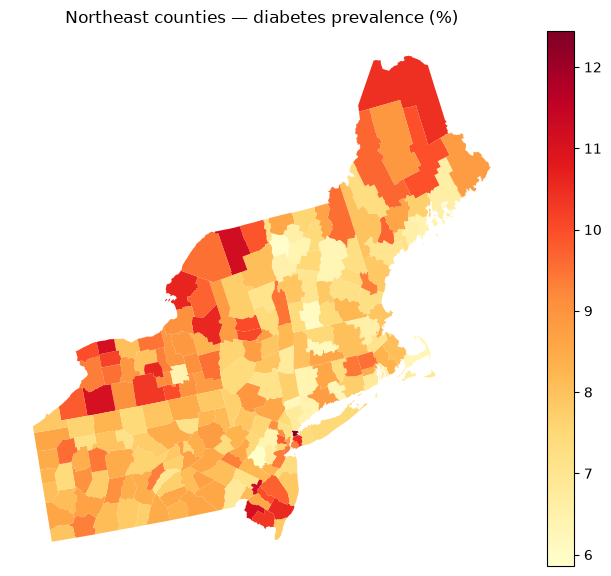

In [4]:
fig, ax = plt.subplots(figsize=(7, 6))
gdf.plot(column=target if target in gdf.columns else None, ax=ax, legend=True, cmap="YlOrRd")
ax.set_title("Northeast counties — diabetes prevalence (%)")
ax.axis("off")
plt.tight_layout()
plt.show()


### 4.2 Your first GWR model

Coordinates are projected (metres), so we use an **adaptive** bandwidth (nearest neighbours) rather than a small fixed degree threshold.


In [5]:
from spatialstats.gwmodel.linear import GWR

gwr = GWR(
    bandwidth=50,       # adaptive: 50 nearest neighbours
    fixed=False,
    kernel="bisquare",
    n_jobs=-1,
)
gwr.fit(X, y, coords)

print(gwr.summary())
print("R²:", round(gwr.score(X, y, coords), 4))


Geographically Weighted Regression (GWR) Summary
  Observations            : 217
  Predictors (incl. int.) : 6
  Bandwidth               : 50.0000
  Kernel                  : bisquare
  Fixed                   : False
  AICc                    : -12.5675
  Effective DF            : 56.2342
  Global R²               : 0.8452

  Local coefficient summary (min / median / max):
    Intercept      : -4.9057 / 2.4207 / 8.9008
    X1             : -0.0092 / 0.0684 / 0.1940
    X2             : 0.0420 / 0.2088 / 0.3525
    X3             : -0.0064 / 0.0003 / 0.0144
    X4             : -1.0331 / -0.0720 / 0.9250
    X5             : -1.2332 / 0.8217 / 2.3512
R²: 0.8452


### 4.3 Key attributes after `fit()`

| Attribute | Shape | Description |
|---|---|---|
| `coef_` | `(n, p+1)` | Local coefficients (incl. intercept) |
| `std_err_` | `(n, p+1)` | Standard errors |
| `t_values_` / `p_values_` | `(n, p+1)` | Inference (BH-corrected p-values) |
| `fitted_` / `residuals_` | `(n,)` | In-sample fit |
| `aicc_` / `bandwidth_` | scalar | Model criteria |


In [6]:
print("coef_ shape:", gwr.coef_.shape)
print("AICc:", round(float(gwr.aicc_), 3))
print("bandwidth_:", gwr.bandwidth_)
print("local intercept range:", gwr.coef_[:, 0].min(), "→", gwr.coef_[:, 0].max())


coef_ shape: (217, 6)
AICc: -12.568
bandwidth_: 50
local intercept range: -4.9057315419550545 → 8.900756994047342


### 4.4 Predict at held-out locations


In [7]:
X_train, X_test = X[:-30], X[-30:]
y_train, y_test = y[:-30], y[-30:]
coords_train, coords_test = coords[:-30], coords[-30:]

gwr_cv = GWR(bandwidth=50, fixed=False, kernel="bisquare", n_jobs=-1)
gwr_cv.fit(X_train, y_train, coords_train)
y_pred = gwr_cv.predict(X_test, coords_test)

rmse = float(np.sqrt(np.mean((y_test - y_pred) ** 2)))
print("Hold-out RMSE:", round(rmse, 3))
print("Predictions (first 5):", np.round(y_pred[:5], 2))


Hold-out RMSE: 0.484
Predictions (first 5): [6.44 8.18 8.12 7.84 8.32]


## 5. Level 2 — Classical GW models (intermediate)

### 5.1 Automatic bandwidth selection


In [8]:
gwr_auto = GWR(
    bandwidth="auto",
    fixed=False,
    kernel="bisquare",
    criterion="AICc",
    n_jobs=-1,
)
gwr_auto.fit(X, y, coords)
print("Selected bandwidth (k-NN):", gwr_auto.bandwidth_)
print("AICc:", round(float(gwr_auto.aicc_), 3), " R²:", round(gwr_auto.score(X, y, coords), 4))


Selected bandwidth (k-NN): 86.0
AICc: -25.087  R²: 0.8151


### 5.2 Kernel comparison


In [9]:
# Use the auto-selected adaptive size for a fair kernel comparison
bw = int(gwr_auto.bandwidth_)
for kernel in ["bisquare", "gaussian", "exponential", "tricube"]:
    m = GWR(bandwidth=bw, fixed=False, kernel=kernel, n_jobs=-1)
    m.fit(X, y, coords)
    print(f"{kernel:12s}  AICc={m.aicc_:8.1f}  R²={m.score(X, y, coords):.3f}")


bisquare      AICc=   -25.1  R²=0.815


gaussian      AICc=    -7.2  R²=0.771


exponential   AICc=    -4.2  R²=0.767


tricube       AICc=   -24.3  R²=0.811


### 5.3 Multiscale GWR (MGWR)

Each covariate gets its own bandwidth via back-fitting. A large bandwidth ⇒ relatively stationary effect; a small bandwidth ⇒ sharp spatial variation.


In [10]:
from spatialstats.gwmodel.linear import MGWR

# Slightly fewer covariates keeps MGWR runtime reasonable for a tutorial
X_mgwr = df[["Obesity", "Physical_Inactivity", "Food_Env_Index", "SVI"]].values.astype(float)

mgwr = MGWR(
    kernel="bisquare",
    fixed=False,
    max_iter=10,
    tol=1.0,
    n_jobs=-1,
)
mgwr.fit(X_mgwr, y, coords)

print("Per-covariate bandwidths:", mgwr.bandwidths_)
print(mgwr.summary())


Per-covariate bandwidths: [6. 6. 6. 6. 6.]
Multiscale GWR (MGWR) Summary
  Observations   : 217
  Kernel         : bisquare
  Fixed          : False
  AICc           : 1744.7773

  Per-covariate bandwidths:
    Intercept      : 6.0000
    X1             : 6.0000
    X2             : 6.0000
    X3             : 6.0000
    X4             : 6.0000


### 5.4 Geographically Weighted Summary Statistics (GWSS)


In [11]:
from spatialstats.gwmodel.linear import GWSS

gwss = GWSS(bandwidth=50, fixed=False, quantile=True)
gwss.fit(X, coords, var_names=features)

print("Local means (first 3 rows):\n", np.round(gwss.local_mean_[:3], 3))
print("Local std (first 3 rows):\n", np.round(gwss.local_std_[:3], 3))
df_stats = gwss.to_dataframe()
df_stats.head()


Local means (first 3 rows):
 [[25.388 21.66  82.208  8.49   0.53 ]
 [26.425 19.711 82.419  8.283  0.411]
 [26.208 20.211 77.738  8.345  0.455]]
Local std (first 3 rows):
 [[ 3.261  3.844 29.051  0.567  0.269]
 [ 2.974  2.618 30.149  0.389  0.219]
 [ 3.067  2.975 28.096  0.421  0.227]]


,mean_Obesity,std_Obesity,var_Obesity,skew_Obesity,kurt_Obesity,mean_Physical_Inactivity,std_Physical_Inactivity,var_Physical_Inactivity,skew_Physical_Inactivity,kurt_Physical_Inactivity,...,median_Obesity,iqr_Obesity,median_Physical_Inactivity,iqr_Physical_Inactivity,median_PCP_rate,iqr_PCP_rate,median_Food_Env_Index,iqr_Food_Env_Index,median_SVI,iqr_SVI
0,25.387962,3.260906,10.633506,-0.333752,-0.144013,21.659628,3.844043,14.776670,0.739007,-0.380727,...,16.80,0.68,17.64,2.12,136.8,9.6,8.1,-0.6,0.6668,0.4131
1,26.424506,2.974173,8.845707,-0.466060,-0.877888,19.711052,2.618495,6.856517,1.031859,1.478746,...,21.48,-2.58,17.34,-0.98,93.8,32.2,8.5,-0.4,0.6184,-0.0255
2,26.208334,3.067337,9.408557,-0.408380,-0.472015,20.210689,2.974584,8.848152,1.289730,1.812294,...,25.42,3.54,17.40,0.64,51.6,20.8,8.1,-0.7,0.1073,0.2489
3,26.226562,3.069966,9.424689,-0.421421,-0.722482,20.009352,3.007614,9.045741,1.180551,1.649317,...,23.98,-0.08,16.52,-0.26,91.6,34.4,8.2,0.1,0.1257,0.1954
4,25.888433,3.169989,10.048829,-0.447269,-0.372224,20.688949,3.475011,12.075704,1.104458,0.756993,...,29.78,-0.64,24.58,2.40,68.2,-15.6,8.1,-0.3,0.8234,0.2689


### 5.5 GWGLM — Poisson counts


In [12]:
from spatialstats.gwmodel.linear import GWGLM

y_counts = df["Diabetes_count"].values.astype(float)
# Offset-style scaling via population is ideal; here we model raw counts
# with a reduced feature set for numerical stability.
X_glm = df[["Obesity", "Physical_Inactivity", "SVI"]].values.astype(float)

gwglm = GWGLM(family="poisson", bandwidth=60, fixed=False, n_jobs=-1)
gwglm.fit(X_glm, y_counts, coords)
print("Poisson GWGLM fitted. coef_ shape:", gwglm.coef_.shape)
print("Mean fitted count:", round(float(np.mean(gwglm.fitted_)), 1))


Poisson GWGLM fitted. coef_ shape: (217, 4)
Mean fitted count: 467278920.9


### 5.6 Mixed (semiparametric) GWR


In [13]:
from spatialstats.gwmodel.linear import MixedGWR

# Index 0 (Obesity) global; remaining covariates local
mixed = MixedGWR(
    fixed_vars=[0],
    varying_vars=[1, 2, 3, 4],
    bandwidth=50,
    fixed=False,
    n_jobs=-1,
)
mixed.fit(X, y, coords)

print("Global coefficients:", np.round(mixed.global_coef_, 4))
print("Local coefficients shape:", mixed.coef_.shape)


Global coefficients: [0.0042]
Local coefficients shape: (217, 5)


## 6. Level 3 — Machine learning GW models

### 6.1 GW Random Forest


In [14]:
from spatialstats.gwmodel.ensemble import GWRandomForest

gwrf = GWRandomForest(
    n_estimators=40,
    bandwidth=50,
    fixed=False,
    kernel="bisquare",
    train_weighted=True,
    predict_weighted=True,
    n_jobs=-1,
    random_state=42,
)
gwrf.fit(X, y, coords)

preds_rf = gwrf.predict(X, coords)
importance_map = gwrf.feature_importance_map()
print("R² (in-sample):", round(gwrf.score(X, y, coords), 4))
print("importance map shape:", importance_map.shape)


R² (in-sample): 0.9959
importance map shape: (217, 5)


### 6.2 GW XGBoost & LightGBM (optional extras)


In [15]:
from spatialstats.gwmodel.ensemble import GWXGBoost, GWLightGBM

gwxgb = GWXGBoost(
    n_estimators=40,
    max_depth=4,
    learning_rate=0.1,
    bandwidth=50,
    fixed=False,
    n_jobs=-1,
)
gwxgb.fit(X, y, coords)
print("GW-XGB R²:", round(gwxgb.score(X, y, coords), 4))

gwlgb = GWLightGBM(
    n_estimators=40,
    num_leaves=15,
    bandwidth=50,
    fixed=False,
    n_jobs=-1,
)
gwlgb.fit(X, y, coords)
print("GW-LGB R²:", round(gwlgb.score(X, y, coords), 4))


GW-XGB R²: 0.9648


GW-LGB R²: 0.7743


## 7. Level 4 — Spatiotemporal & multivariate

### 7.1 GTWR on California PM2.5 (subsample)

We take a spatial–temporal subsample of `CA_pm25_2025.csv` (daily monitors) so the tutorial stays interactive.


In [16]:
from spatialstats.gwmodel.spatiotemporal import GTWR

pm = pd.read_csv(DATA / "CA_pm25_2025.csv", parse_dates=["Date"])
pm = pm.dropna(subset=["Lat", "Long", "Daily_PM2.5_ug_m3", "Daily_AQI"]).copy()
pm["doy"] = pm["Date"].dt.dayofyear.astype(float)

# Keep a compact panel: a few sites × first 60 days
top_sites = pm["Site ID"].value_counts().head(25).index
pm_sub = pm[pm["Site ID"].isin(top_sites)].sort_values(["Site ID", "Date"]).groupby("Site ID").head(60)
pm_sub = pm_sub.sample(n=min(400, len(pm_sub)), random_state=42).reset_index(drop=True)

coords_pm = pm_sub[["Long", "Lat"]].values.astype(float)
times_pm = pm_sub["doy"].values.astype(float)
# Simple meteorological proxies unavailable → use AQI-related structure via day + location only
# Construct two synthetic but spatially varying covariates from coordinates for the demo
X_pm = np.column_stack([
    coords_pm[:, 0],
    coords_pm[:, 1],
    times_pm / 365.0,
])
y_pm = pm_sub["Daily_PM2.5_ug_m3"].values.astype(float)

print("PM2.5 subsample:", X_pm.shape, "time range:", times_pm.min(), "–", times_pm.max())

gtwr = GTWR(
    bandwidth_s=15,
    lambda_=1.0,
    fixed=False,
    kernel="bisquare",
    n_jobs=-1,
)
gtwr.fit(X_pm, y_pm, coords_pm, times_pm)
print("GTWR AICc:", round(float(gtwr.aicc_), 2))
print("Predictions shape:", gtwr.predict(X_pm, coords_pm, times_pm).shape)


PM2.5 subsample: (400, 3) time range: 1.0 – 45.0


GTWR AICc: 1836.73
Predictions shape: (400,)


### 7.2 GWPCA on diabetes covariates


In [17]:
from spatialstats.gwmodel.multivariate import GWPCA

gwpca = GWPCA(
    n_components=2,
    bandwidth=50,
    fixed=False,
    robust=False,
)
gwpca.fit(X, coords)

print("Local loadings:", gwpca.local_loadings_.shape)
print("Local scores:", gwpca.local_scores_.shape)
print("PVE (first 3 locations):\n", np.round(gwpca.local_pve_[:3], 3))


Local loadings: (217, 5, 2)
Local scores: (217, 2)
PVE (first 3 locations):
 [[0.977 0.017]
 [0.986 0.011]
 [0.982 0.013]]


## 8. Level 5 — Deep learning (GNNWR)

Requires PyTorch (`pip install pyspatialstats[deep]`). We use a small network and few epochs for a quick demo.


In [18]:
try:
    from spatialstats.gwmodel.deep import GNNWR

    gnnwr = GNNWR(
        hidden_layers=[32, 16],
        n_epochs=25,
        batch_size=64,
        learning_rate=1e-3,
        patience=10,
        device="auto",
        random_state=42,
    )
    gnnwr.fit(X, y, coords)
    print("GNNWR R²:", round(gnnwr.score(X, y, coords), 4))
    print("Training loss (first 5):", [round(float(v), 4) for v in gnnwr.train_loss_[:5]])
    print("Local coefficients:", gnnwr.coef_.shape)
except Exception as exc:
    print("GNNWR skipped:", type(exc).__name__, str(exc)[:200])


GNNWR R²: 0.7336
Training loss (first 5): [0.3672, 0.3672, 0.3672, 0.3672, 0.3672]
Local coefficients: (217, 6)


## 9. Diagnostics & model checking

Re-fit a reference GWR (auto bandwidth) for residual diagnostics.


In [19]:
from spatialstats.gwmodel.diagnostics import (
    moran_test, f3_test, monte_carlo_variability,
    local_vif, local_condition_number,
)
from spatialstats.gwmodel.core.kernels import SpatialKernel
from spatialstats.gwmodel.utils.distance import pairwise_distances

gwr_ref = GWR(bandwidth="auto", fixed=False, kernel="bisquare", n_jobs=-1)
gwr_ref.fit(X, y, coords)

result = moran_test(gwr_ref.residuals_, coords, k=8)
print("Moran's I:", round(float(result["I"]), 4))
print("p-value:  ", round(float(result["p_value"]), 4))


Moran's I: -0.0036
p-value:   0.9648


In [20]:
hat_diag = np.full(len(y), gwr_ref.effective_df_ / len(y))
f3 = f3_test(gwr_ref.coef_, gwr_ref.residuals_, hat_diag)
for j, (stat, p) in enumerate(zip(f3["statistic"], f3["p_value"])):
    name = "Intercept" if j == 0 else features[j - 1]
    print(f"{name:22s}  F3={stat:8.3f}  p={p:.4f}")


Intercept               F3=  10.317  p=0.0000
Obesity                 F3=   0.004  p=1.0000
Physical_Inactivity     F3=   0.011  p=1.0000
PCP_rate                F3=   0.000  p=1.0000
Food_Env_Index          F3=   0.326  p=1.0000
SVI                     F3=   0.851  p=0.8700


In [21]:
mc = monte_carlo_variability(gwr_ref.coef_, n_sim=99)  # 99 for tutorial speed
print("Monte Carlo p-values:", np.round(mc["p_value"], 4))

sig = gwr_ref.local_significance(alpha=0.05)
print("Significant local coeffs (fraction):", np.round(sig.mean(axis=0), 3))


Monte Carlo p-values: [1. 1. 1. 1. 1. 1.]
Significant local coeffs (fraction): [0.    0.    0.889 0.    0.    0.   ]


In [22]:
X_int = np.column_stack([np.ones(len(y)), X])
D = pairwise_distances(coords)
kernel = SpatialKernel("bisquare", fixed=False, bandwidth=gwr_ref.bandwidth_)

vif = local_vif(X_int, D, kernel)
cn = local_condition_number(gwr_ref.coef_, X_int, D, kernel)
print("VIF shape:", vif.shape, "  median VIF by column:", np.round(np.nanmedian(vif, axis=0), 2))
print("Condition number median:", round(float(np.nanmedian(cn)), 2))


VIF shape: (217, 6)   median VIF by column: [0.   2.21 2.73 1.34 1.57 2.18]
Condition number median: 7645510.06


## 10. Visualization


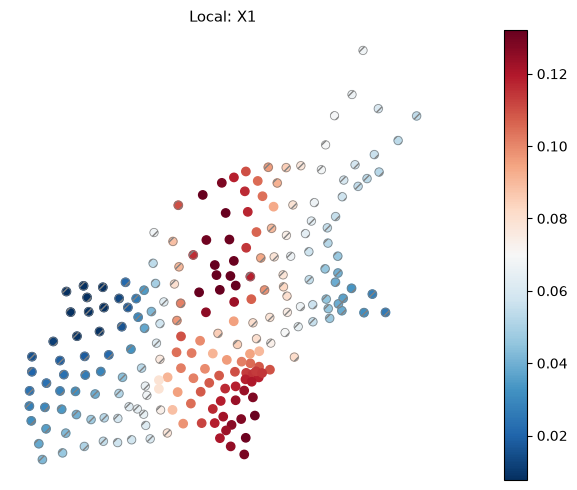

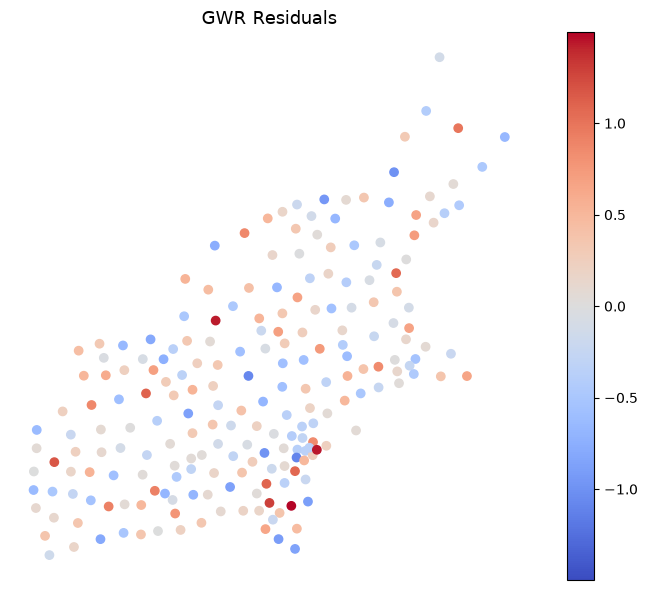

In [23]:
from spatialstats.gwmodel.visualization import plot_local_coefficients, plot_residuals

# Point GeoDataFrame aligned with model rows
gdf_map = gpd.GeoDataFrame(
    df.copy(),
    geometry=gpd.points_from_xy(df["X"], df["Y"]),
    crs=gdf.crs,
)

fig = plot_local_coefficients(
    gwr_ref,
    gdf_map,
    covariate=1,  # Obesity coefficient
    significance=True,
    alpha=0.05,
    cmap="RdBu_r",
)
plt.show()

fig2 = plot_residuals(gwr_ref, gdf_map, cmap="coolwarm")
plt.show()


## 11. Performance: multi-core CPU & GPU


In [24]:
from spatialstats import set_compute_options

set_compute_options(n_jobs=-1, device="auto")

try:
    import torch
    from spatialstats.gwmodel.utils.compute import resolve_torch_device
    print("CUDA available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))
    print("PySpatialStats will use:", resolve_torch_device("auto"))
except Exception as exc:
    print("Torch check skipped:", exc)


CUDA available: True
GPU: NVIDIA RTX A5500 Laptop GPU
PySpatialStats will use: cuda


## 12. End-to-end workflow (Atlantic counties)

Load the larger Atlantic diabetes layer, explore with GWSS, fit GWR, check residual autocorrelation, and compare against GW-RF.


In [25]:
atl = pd.read_csv(DATA / "diabetes_atlantic.csv").dropna(subset=features + [target, "X", "Y"])
coords_a = atl[["X", "Y"]].values.astype(float)
X_a = atl[features].values.astype(float)
y_a = atl[target].values.astype(float)
gdf_a = gpd.GeoDataFrame(atl, geometry=gpd.points_from_xy(atl["X"], atl["Y"]))

print(f"Atlantic sample: n={len(atl)}")

gwss_a = GWSS(bandwidth=60, fixed=False, quantile=False)
gwss_a.fit(X_a, coords_a, var_names=features)

gwr_a = GWR(bandwidth="auto", fixed=False, kernel="bisquare", n_jobs=-1)
gwr_a.fit(X_a, y_a, coords_a)

moran_a = moran_test(gwr_a.residuals_, coords_a, k=8)
print(f"GWR R²={gwr_a.score(X_a, y_a, coords_a):.4f}  bw={gwr_a.bandwidth_}  Moran p={moran_a['p_value']:.4f}")

gwrf_a = GWRandomForest(n_estimators=30, bandwidth=60, fixed=False, n_jobs=-1, random_state=0)
gwrf_a.fit(X_a, y_a, coords_a)
print(f"GW-RF R²={gwrf_a.score(X_a, y_a, coords_a):.4f}")


Atlantic sample: n=666


GWR R²=0.8415  bw=82.0  Moran p=0.8756


GW-RF R²=1.0000


### 12.2 Quick model-family comparison (Northeast)


In [26]:
models = {
    "GWR": GWR(bandwidth=int(gwr_ref.bandwidth_), fixed=False, n_jobs=-1),
    "GW-RF": GWRandomForest(n_estimators=30, bandwidth=int(gwr_ref.bandwidth_), fixed=False, n_jobs=-1, random_state=1),
}

rows = []
for name, model in models.items():
    model.fit(X, y, coords)
    rows.append({"model": name, "R2": round(model.score(X, y, coords), 4)})

pd.DataFrame(rows)


,model,R2
0,GWR,0.8151
1,GW-RF,0.9950


## 13. Choosing the right model

| Research question | Recommended model |
|---|---|
| How does the effect of X on Y vary across space? | `GWR`, `MGWR` |
| Do predictors operate at different scales? | `MGWR` |
| Is the relationship non-linear? | `GWRandomForest`, `GWXGBoost` |
| Space + time interaction? | `GTWR`, `GTNNWR` |
| Local multivariate structure? | `GWPCA` |
| Some covariates global, others local? | `MixedGWR` |
| Count / binary outcomes? | `GWGLM` |


## 14. Troubleshooting (quick reference)

| Problem | Likely cause | Fix |
|---|---|---|
| `LinAlgError` during fit | Local collinearity | Reduce `p`; increase bandwidth; check VIF |
| All p-values = 1 | Bandwidth too large | Decrease bandwidth; use adaptive kernel |
| Very slow fit | Large `n` | Use `n_jobs=-1`; try GW-RF / GW-XGB |
| `ImportError: PyTorch` | Missing deep extra | `pip install pyspatialstats[deep]` |
| Negative local R² | Small local sample | Increase adaptive bandwidth |


## 15. Further reading

- Fotheringham, Brunsdon & Charlton (2002). *Geographically Weighted Regression.* Wiley.
- Oshan et al. (2019). mgwr: A Python Implementation of Multiscale GWR. *ISPRS IJGI*.
- Du et al. (2020). Geographically Neural Network Weighted Regression. *IJGIS*.
- Wu et al. (2021). Geographically and Temporally Neural Network Weighted Regression. *IJGIS*.

---

*PySpatialStats — BSD-3-Clause License*
